# `wb-api-tools` — quick-start examples

Five illustrative examples covering the full library surface. Each shows
the output inline (DataFrame tables and figures) so GitHub renders the
notebook directly — no need to clone or install to see what the package does.

Run all cells to reproduce locally; the same 5 examples are also available
as a plain Python script at `examples/readme_examples.py` (which also
writes the PNG/SVG figures committed to `docs/figures/`).

**Numbering and theme mirror the Stata `wbopendata_examples.ado` patterns:**

| # | Example | Stata analogue |
| --- | --- | --- |
| 1 | Population time-series, multiple countries | line chart |
| 2 | G7 GDP per capita PPP cross-section | bar chart |
| 3 | Poverty vs GDP per capita scatter | Stata example04 |
| 4 | Discovery workflow: search -> info -> fetch | — |
| 5 | Enrich a user DataFrame with country context | Stata example05 |


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import wb_api_tools as wb

plt.rcParams.update({
    'figure.figsize': (8, 4.5), 'figure.dpi': 100,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10,
})

print('wb_api_tools version:', wb.__version__)


wb_api_tools version: 0.2.1


## Example 1 — Population time-series

Three countries, one indicator (`SP.POP.TOTL`), 2000-2023. Returns a tidy
DataFrame; we re-plot as a line chart with one line per country.


In [2]:
df = wb.get_data(['SP.POP.TOTL'], 'BRA;USA;IND', date='2000:2023', long=True, no_basic=True)
df = df.dropna(subset=['value']).copy()
df['date'] = pd.to_numeric(df['date'], errors='coerce').astype('Int64')
df['pop_billions'] = df['value'] / 1e9
df.head(6)[['country', 'date', 'pop_billions']]


,country,date,pop_billions
0,Brazil,2000,0.174018
3,Brazil,2001,0.176301
6,Brazil,2002,0.178503
9,Brazil,2003,0.180623
12,Brazil,2004,0.182675
15,Brazil,2005,0.184688


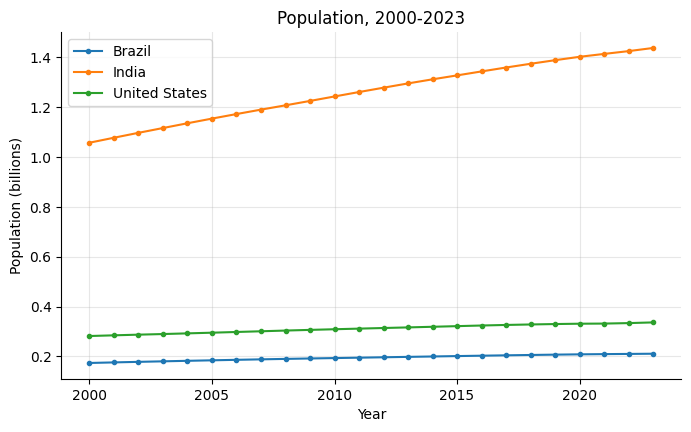

In [3]:
fig, ax = plt.subplots()
for country, sub in df.sort_values('date').groupby('country'):
    ax.plot(sub['date'], sub['pop_billions'], marker='o', markersize=3, label=country)
ax.set_title('Population, 2000-2023')
ax.set_xlabel('Year'); ax.set_ylabel('Population (billions)')
ax.legend(); plt.show()


## Example 2 — GDP per capita PPP for the G7 (latest year)

Cross-country bar chart. Single year (2022), one indicator, 7 countries.


In [4]:
g7 = 'CAN;DEU;FRA;GBR;ITA;JPN;USA'
df2 = wb.get_data(['NY.GDP.PCAP.PP.KD'], g7, date='2022', long=True, no_basic=True)
df2 = df2.dropna(subset=['value']).sort_values('value', ascending=True).copy()
df2['gdp_pcap_k'] = df2['value'] / 1000
df2[['country', 'date', 'gdp_pcap_k']]


,country,date,gdp_pcap_k
5,Japan,2022,44.972344
4,Italy,2022,52.333327
3,United Kingdom,2022,53.139151
2,France,2022,53.673814
0,Canada,2022,58.321061
1,Germany,2022,63.676088
6,United States,2022,72.679258


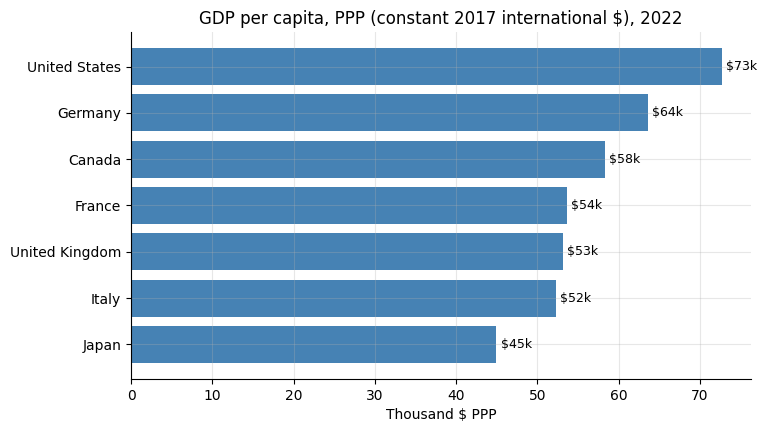

In [5]:
fig, ax = plt.subplots()
ax.barh(df2['country'], df2['gdp_pcap_k'], color='steelblue')
for i, v in enumerate(df2['gdp_pcap_k']):
    ax.text(v + 0.5, i, f'${v:,.0f}k', va='center', fontsize=9)
ax.set_title('GDP per capita, PPP (constant 2017 international $), 2022')
ax.set_xlabel('Thousand $ PPP'); plt.show()


## Example 3 — Poverty headcount vs GDP per capita (cross-section)

Two indicators, all countries, single year. Mirrors Stata
`wbopendata_examples.ado` example04. Region colour-coded; log-x.

We compare three candidate fits — **linear in log(GDP)**,
**quadratic in log(GDP)**, **logistic 4PL** — and overlay the
one with the highest R². Logistic wins on principled grounds too:
poverty headcount is bounded in $[0, 100\%]$, so a sigmoid that
respects both asymptotes is the right family.


In [6]:
df3 = wb.get_data(['SI.POV.DDAY', 'NY.GDP.PCAP.PP.KD'], 'all', date='2019', no_basic=False)
df3 = df3.dropna(subset=['SI.POV.DDAY', 'NY.GDP.PCAP.PP.KD'])
df3 = df3[df3['region'].notna() & (df3['region'] != 'NA')]
print(f'countries with both indicators in 2019: {len(df3)}')
df3[['countryiso3code', 'country', 'SI.POV.DDAY', 'NY.GDP.PCAP.PP.KD']] \
    .sort_values('SI.POV.DDAY', ascending=False).head(8)


countries with both indicators in 2019: 78


,countryiso3code,country,SI.POV.DDAY,NY.GDP.PCAP.PP.KD
153,MOZ,Mozambique,81.6,1528.889884
156,MWI,Malawi,75.4,1687.289449
231,UGA,Uganda,59.8,2689.410091
246,ZWE,Zimbabwe,49.2,4993.843839
240,VUT,Vanuatu,19.5,3512.071973
91,HND,Honduras,18.8,6264.018843
243,XKX,Kosovo,11.3,11774.117851
43,COL,Colombia,11.3,17336.771603


In [7]:
import numpy as np
from scipy.optimize import curve_fit

x = df3['NY.GDP.PCAP.PP.KD'].to_numpy(dtype=float)
y = df3['SI.POV.DDAY'].to_numpy(dtype=float)
log_x = np.log10(x)
ss_tot = float(np.sum((y - y.mean())**2))
r2 = lambda y_hat: 1.0 - float(np.sum((y - y_hat)**2)) / ss_tot

# 1. Linear in log10(GDP)
b_lin, a_lin = np.polyfit(log_x, y, 1)
fit_lin = lambda x: b_lin * np.log10(x) + a_lin

# 2. Quadratic in log10(GDP)
coefs_q = np.polyfit(log_x, y, 2)
fit_q = lambda x: np.polyval(coefs_q, np.log10(x))

# 3. Logistic 4PL: y = d + (a-d) / (1 + (x/c)**b)
def logistic_4pl(x, a, b, c, d):
    return d + (a - d) / (1.0 + (x / c) ** b)
popt, _ = curve_fit(logistic_4pl, x, y,
                    p0=[100.0, 1.0, float(np.median(x)), 0.0], maxfev=20000)
fit_log = lambda x, _p=popt: logistic_4pl(x, *_p)

fits = [('Linear (log GDP)', r2(fit_lin(x)), fit_lin),
        ('Quadratic (log GDP)', r2(fit_q(x)), fit_q),
        ('Logistic 4PL', r2(fit_log(x)), fit_log)]
best = max(fits, key=lambda f: f[1])
print('Fit comparison (higher R^2 = better):')
for name, r, _ in fits:
    marker = '  <-- selected' if (name, r) == (best[0], best[1]) else ''
    print(f'  {name:22s}  R^2 = {r:.3f}{marker}')


Fit comparison (higher R^2 = better):
  Linear (log GDP)        R^2 = 0.503
  Quadratic (log GDP)     R^2 = 0.775
  Logistic 4PL            R^2 = 0.834  <-- selected


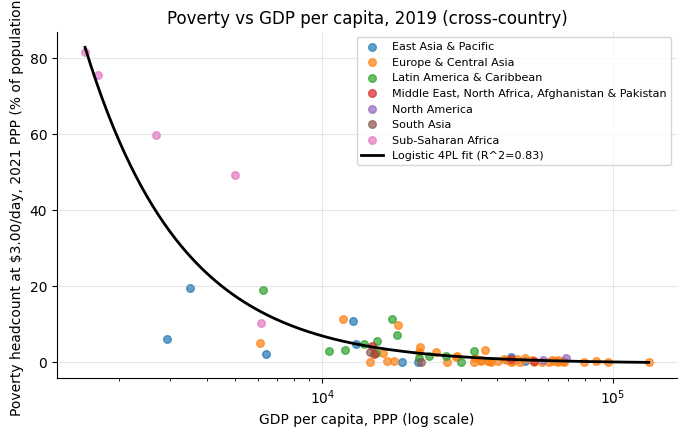

In [8]:
fig, ax = plt.subplots()
for region, sub in df3.groupby('regionname'):
    ax.scatter(sub['NY.GDP.PCAP.PP.KD'], sub['SI.POV.DDAY'], alpha=0.7, s=30, label=region)
x_smooth = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
ax.plot(x_smooth, best[2](x_smooth), color='black', linewidth=2,
        label=f'{best[0]} fit (R^2={best[1]:.2f})')
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, PPP (log scale)')
ax.set_ylabel('Poverty headcount at $3.00/day, 2021 PPP (% of population)')
ax.set_title('Poverty vs GDP per capita, 2019 (cross-country)')
ax.legend(fontsize=8, loc='upper right'); plt.show()


## Example 4 — Discovery workflow

`search` for an indicator by keyword, `info` to inspect its full metadata
(from the local YAML cache after `wb-api-tools sync`).


In [9]:
res = wb.search('education spending', limit=3)
print(f"total matches: {res['total']:,}; page {res['page']}/{res['pages']}")
for r in res['results']:
    print(f"  [{r['code']:<32}] {r['name']}")


total matches: 19; page 1/7
  [PER.HH.MGT.SHARE                ] World Bank: Share of total household education spending/school fees appropriated to provincial/regional/central government levels from the school level (%)
  [PER.HH.SAL.SHARE                ] World Bank: Share of total household education spending for salaries (%)
  [PER.OC.FIN.TOT                  ] World Bank: Share of total education spending for scholarships (%)


In [10]:
meta = wb.info('SE.XPD.TOTL.GD.ZS')
{k: v for k, v in meta.items() if k != 'description'} if meta else None


{'code': 'SE.XPD.TOTL.GD.ZS',
 'name': 'Government expenditure on education, total (% of GDP)',
 'source_id': '2',
 'source_name': 'World Development Indicators',
 'topic_ids': ['4'],
 'topic_names': ['Education'],
 'unit': '',
 'source_org': 'Data API, UN Educational, Scientific and Cultural Organization (UNESCO), uri:\nhttps://databrowser.uis.unesco.org/resources, note: The data are obtained through the UIS API.  Detailed documentation\nis available at: https://api.uis.unesco.org/api/public/documentation/, publisher: UNESCO Institute for Statistics (UIS),\ndate accessed: 2026-03-19, date published: 2026-02',
 'note': '',
 'limited_data': False}

## Example 5 — Enrich a user DataFrame with country context

Mirrors Stata `wbopendata, match(varname) [basic geo]`. Left-join semantics;
input frame not mutated.


In [11]:
user_df = pd.DataFrame({
    'iso3': ['BRA', 'USA', 'IND', 'DEU', 'JPN', 'NGA', 'EGY'],
    'my_metric': [1.2, 3.4, 5.6, 7.8, 9.0, 2.1, 4.3],
})
user_df


,iso3,my_metric
0,BRA,1.2
1,USA,3.4
2,IND,5.6
3,DEU,7.8
4,JPN,9.0
5,NGA,2.1
6,EGY,4.3


In [12]:
enriched = wb.enrich_country_context(user_df, iso_col='iso3', geo=True)
enriched[['iso3', 'my_metric', 'region', 'incomelevelname',
          'capital', 'latitude', 'longitude']]


,iso3,my_metric,region,incomelevelname,capital,latitude,longitude
0,BRA,1.2,LCN,Upper middle income,Brasilia,-15.7801,-47.9292
1,USA,3.4,NAC,High income,Washington D.C.,38.8895,-77.032
2,IND,5.6,SAS,Lower middle income,New Delhi,28.6353,77.225
3,DEU,7.8,ECS,High income,Berlin,52.5235,13.4115
4,JPN,9.0,EAS,High income,Tokyo,35.67,139.77
5,NGA,2.1,SSF,Lower middle income,Abuja,9.05804,7.48906
6,EGY,4.3,MEA,Lower middle income,Cairo,30.0982,31.2461


---

### Next steps

- **CLI counterpart**: every example above has a `wb-api-tools <subcmd>` form.
  Run `wb-api-tools --help` for the full list.
- **Full reference**: [`docs/PYTHON_USER_GUIDE.md`](../docs/PYTHON_USER_GUIDE.md).
- **Stata parity**: [`docs/PYTHON_USER_GUIDE.md` §5](../docs/PYTHON_USER_GUIDE.md#5-parity-with-stata-wbopendata).
